   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 22.8 MB/s eta 0:00:00
GC Content: 51.35%
Found 0 ORFs


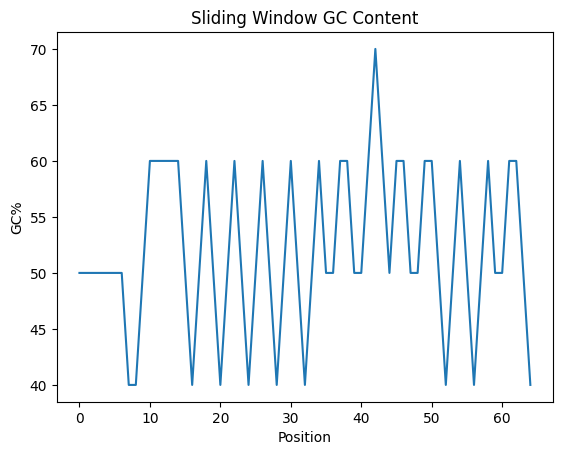

In [1]:
# Genomic Analysis - GC Content & ORF Finder
# Author: [Adınız]
# Date: 2025
# Description: Basic analysis on DNA sequences using Biopython and Python standard libraries

!pip install biopython

from Bio import SeqIO
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import random

# -----------------------
# 1. Example FASTA Read
# -----------------------
# Create a sample FASTA file
fasta_example = """>sequence1
ATGCGCGATATAGCGCTAGCTAGCTAGCATGCTAGCTAGCTAGCAGCTAGCGATGCTAGCATGCTAGCAGCTAA
"""
with open("sample.fasta", "w") as f:
    f.write(fasta_example)

# Load sequence from FASTA
record = SeqIO.read("sample.fasta", "fasta")
sequence = str(record.seq).upper()

# -----------------------
# 2. GC Content Calculation
# -----------------------
def calculate_gc_content(seq):
    g = seq.count("G")
    c = seq.count("C")
    gc_content = 100 * (g + c) / len(seq)
    return round(gc_content, 2)

gc = calculate_gc_content(sequence)
print(f"GC Content: {gc}%")

# -----------------------
# 3. ORF Finder
# -----------------------
def find_orfs(seq, min_len=30):
    orfs = []
    start_codon = "ATG"
    stop_codons = ["TAA", "TAG", "TGA"]

    for frame in range(3):
        for i in range(frame, len(seq) - 3, 3):
            codon = seq[i:i+3]
            if codon == start_codon:
                for j in range(i+3, len(seq)-2, 3):
                    stop = seq[j:j+3]
                    if stop in stop_codons:
                        orf = seq[i:j+3]
                        if len(orf) >= min_len:
                            orfs.append((i, j+3, orf))
                        break
    return orfs

orfs = find_orfs(sequence)
print(f"Found {len(orfs)} ORFs")
for i, (start, end, orf) in enumerate(orfs):
    print(f"ORF {i+1}: Start={start}, End={end}, Length={end-start}")

# -----------------------
# 4. Optional: GC Content Plot (Sliding Window)
# -----------------------
def gc_content_sliding_window(seq, window=10):
    gc_values = []
    for i in range(0, len(seq)-window+1):
        window_seq = seq[i:i+window]
        gc_values.append(calculate_gc_content(window_seq))
    return gc_values

gc_plot = gc_content_sliding_window(sequence, window=10)
plt.plot(gc_plot)
plt.title("Sliding Window GC Content")
plt.xlabel("Position")
plt.ylabel("GC%")
plt.show()
